## NAME:MEGHA RAJEEV 
## REG NO: 23MIM10047 
## APPLICATION NO 

## DATA UNDERSTANDING

In [30]:
import requests
import pandas as pd

def fetch_weather(latitude, longitude):
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
        "forecast_days": 7
    }

    response = requests.get(url, params=params)
    data = response.json()

    hourly = data["hourly"]

    df = pd.DataFrame({
        "Time": hourly["time"],
        "Temperature": hourly["temperature_2m"],
        "Relative_Humidity": hourly["relative_humidity_2m"],
        "Surface_Pressure": hourly["surface_pressure"],
        "Wind_Speed": hourly["wind_speed_10m"]
    })

    return df

In [31]:
df_delhi = fetch_weather(28.6139, 77.2090)

df_delhi["Weather_Class"] = "Warm"

In [32]:
df_munnar = fetch_weather(10.0889, 77.0595)

df_munnar["Weather_Class"] = "Cool"

In [33]:
df = pd.concat([df_delhi, df_munnar], ignore_index=True)

In [34]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [35]:
print(df["Weather_Class"].value_counts())

Weather_Class
Warm    168
Cool    168
Name: count, dtype: int64


In [36]:
df.head()

,Time,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,2026-07-31T00:00,26.9,91,974.7,9.7,Warm
1,2026-08-01T14:00,28.2,90,974.3,6.7,Warm
2,2026-08-02T10:00,17.9,100,855.5,16.9,Cool
3,2026-08-01T12:00,29.1,85,972.6,9.0,Warm
4,2026-08-01T13:00,16.7,100,854.7,14.5,Cool


In [37]:
print(df.shape)

(336, 6)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               336 non-null    object 
 1   Temperature        336 non-null    float64
 2   Relative_Humidity  336 non-null    int64  
 3   Surface_Pressure   336 non-null    float64
 4   Wind_Speed         336 non-null    float64
 5   Weather_Class      336 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 15.9+ KB


In [39]:
df.describe()

,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed
count,336.000000,336.000000,336.000000,336.000000
mean,22.709821,92.217262,915.112798,11.625298
std,5.830557,8.388895,60.032194,5.368508
min,15.700000,69.000000,852.300000,0.400000
25%,16.900000,88.000000,855.300000,6.775000
50%,23.300000,95.000000,915.300000,13.150000
75%,27.900000,99.000000,975.200000,16.600000
max,32.400000,100.000000,977.400000,20.400000


In [40]:
print(df.columns.tolist())

['Time', 'Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed', 'Weather_Class']


In [41]:
print(df.isnull().sum())

Time                 0
Temperature          0
Relative_Humidity    0
Surface_Pressure     0
Wind_Speed           0
Weather_Class        0
dtype: int64


In [42]:
print("Input Features:")
print([
    "Temperature",
    "Relative_Humidity",
    "Surface_Pressure",
    "Wind_Speed"
])

print("\nTarget Variable:")
print("Weather_Class")

Input Features:
['Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed']

Target Variable:
Weather_Class


## Exploratory Data Analysis (EDA)

In [43]:
print("Dataset Shape:", df.shape)

Dataset Shape: (336, 6)


In [44]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Time', 'Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed', 'Weather_Class']


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               336 non-null    object 
 1   Temperature        336 non-null    float64
 2   Relative_Humidity  336 non-null    int64  
 3   Surface_Pressure   336 non-null    float64
 4   Wind_Speed         336 non-null    float64
 5   Weather_Class      336 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 15.9+ KB


In [46]:
df.describe()

,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed
count,336.000000,336.000000,336.000000,336.000000
mean,22.709821,92.217262,915.112798,11.625298
std,5.830557,8.388895,60.032194,5.368508
min,15.700000,69.000000,852.300000,0.400000
25%,16.900000,88.000000,855.300000,6.775000
50%,23.300000,95.000000,915.300000,13.150000
75%,27.900000,99.000000,975.200000,16.600000
max,32.400000,100.000000,977.400000,20.400000


In [47]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Time                 0
Temperature          0
Relative_Humidity    0
Surface_Pressure     0
Wind_Speed           0
Weather_Class        0
dtype: int64


In [48]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Weather_Class
Warm    168
Cool    168
Name: count, dtype: int64


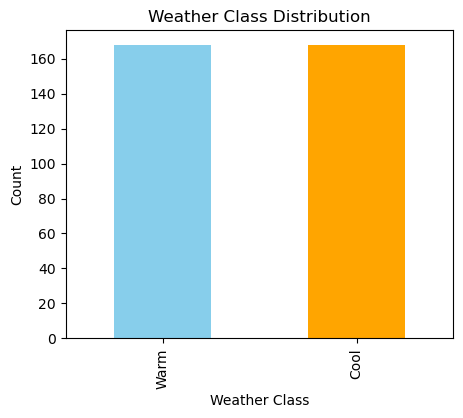

In [49]:
print(df["Weather_Class"].value_counts())

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

df["Weather_Class"].value_counts().plot(
    kind="bar",
    color=["skyblue","orange"]
)

plt.title("Weather Class Distribution")
plt.xlabel("Weather Class")
plt.ylabel("Count")
plt.show()

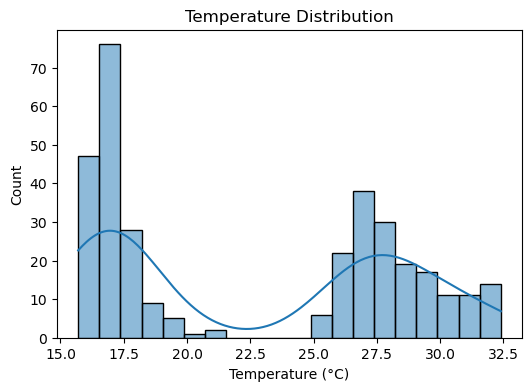

In [50]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(df["Temperature"], bins=20, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.show()

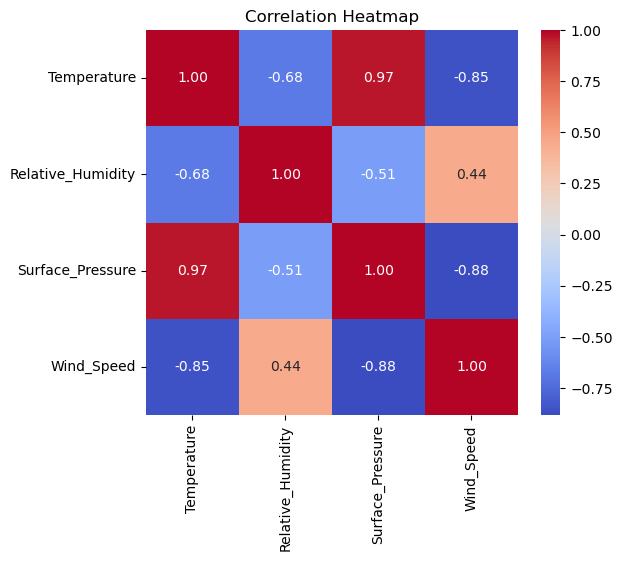

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df.drop(columns=["Time","Weather_Class"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

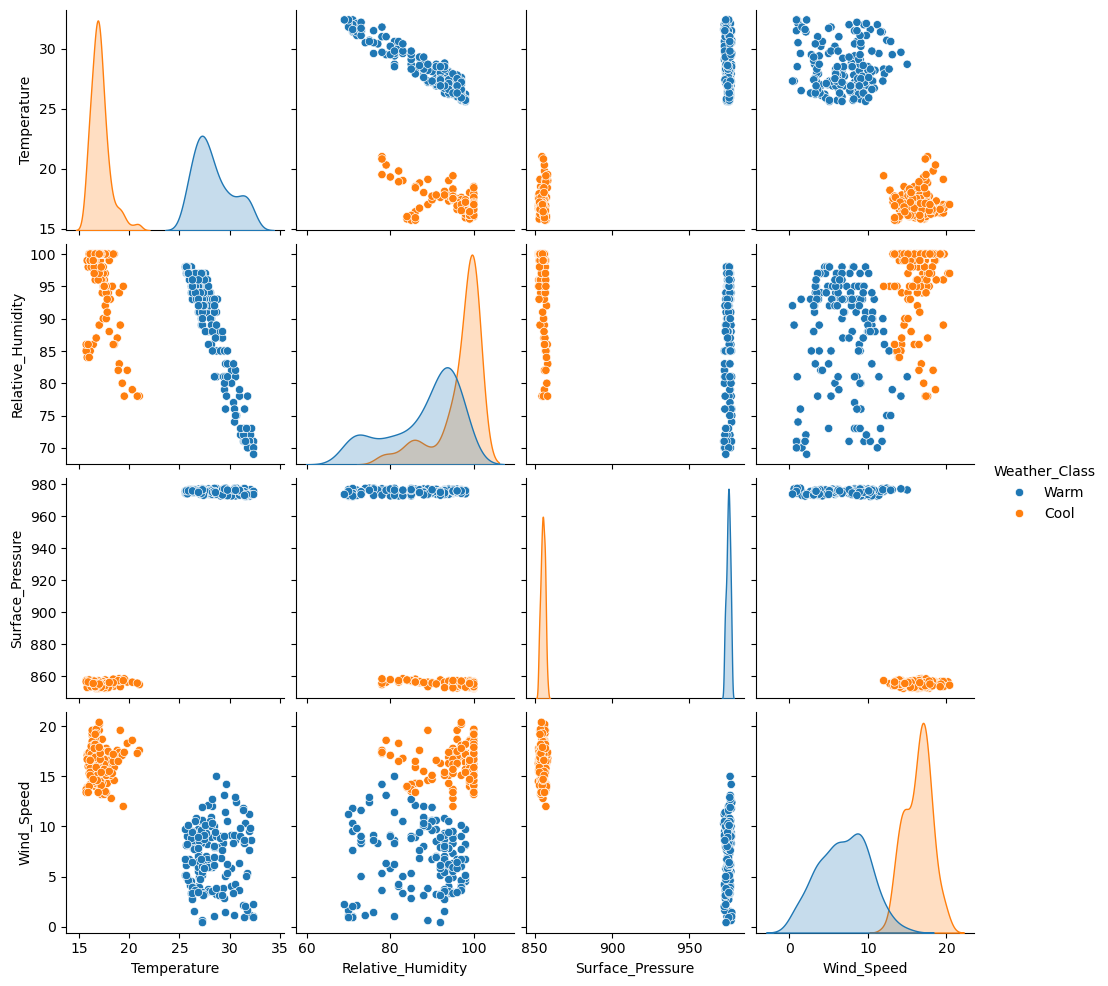

In [53]:
sns.pairplot(
    df,
    hue="Weather_Class",
    vars=[
        "Temperature",
        "Relative_Humidity",
        "Surface_Pressure",
        "Wind_Speed"
    ]
)

plt.show()

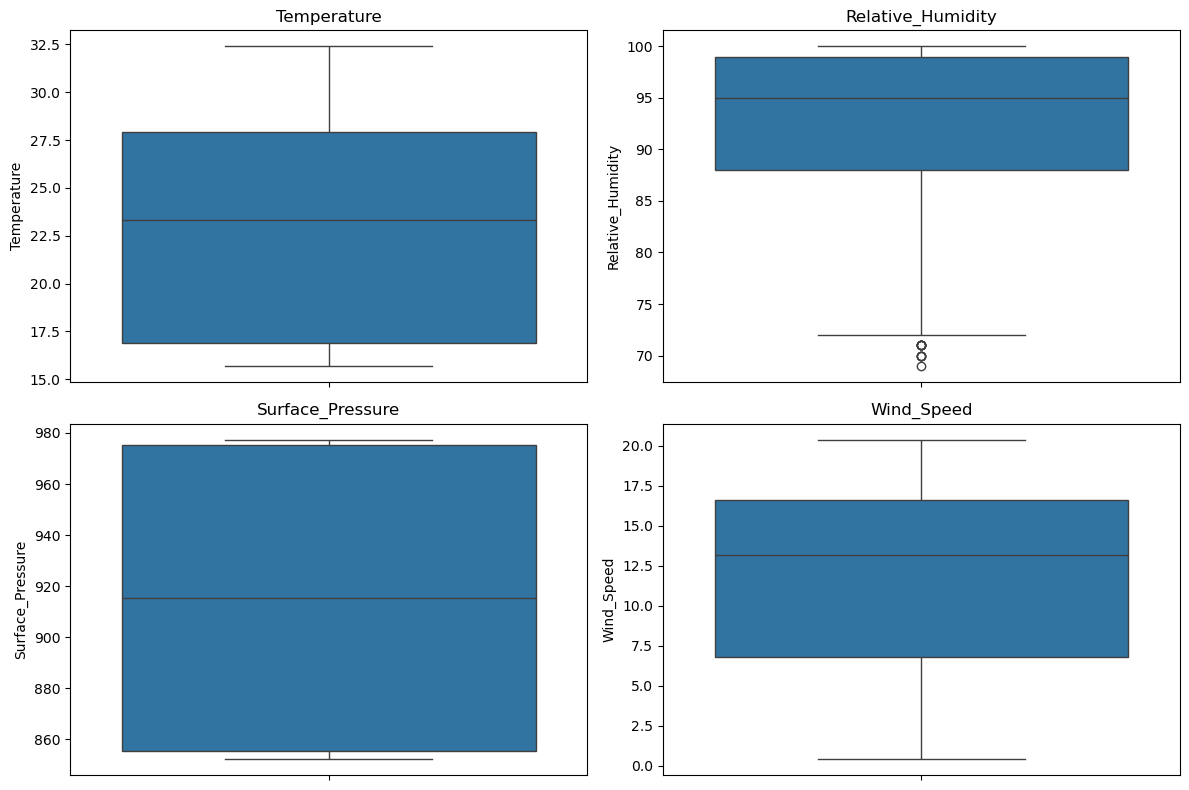

In [54]:
features = [
    "Temperature",
    "Relative_Humidity",
    "Surface_Pressure",
    "Wind_Speed"
]

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()

plt.show()

## DATA PREPROCESSING

In [55]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Time                 0
Temperature          0
Relative_Humidity    0
Surface_Pressure     0
Wind_Speed           0
Weather_Class        0
dtype: int64


In [56]:
df = df.dropna()

In [57]:
df = df.drop(columns=['Time'])

In [64]:
print(df.columns)

Index(['Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed',
       'Weather_Class'],
      dtype='object')


In [58]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Weather_Class'] = encoder.fit_transform(df['Weather_Class'])

print(df.head())

   Temperature  Relative_Humidity  Surface_Pressure  Wind_Speed  Weather_Class
0         26.9                 91             974.7         9.7              1
1         28.2                 90             974.3         6.7              1
2         17.9                100             855.5        16.9              0
3         29.1                 85             972.6         9.0              1
4         16.7                100             854.7        14.5              0


In [65]:
print(df[['Weather_Class']].head())

print(dict(zip(encoder.classes_,
               encoder.transform(encoder.classes_))))

   Weather_Class
0              1
1              1
2              0
3              1
4              0
{'Cool': np.int64(0), 'Warm': np.int64(1)}


In [60]:
X = df[['Temperature',
        'Relative_Humidity',
        'Surface_Pressure',
        'Wind_Speed']]

y = df['Weather_Class']

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10,
    stratify=y
)

In [83]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (268, 4)
Testing data : (68, 4)


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [85]:
print(X_train[:5])

[[-1.01108286  0.95201972 -1.01030939  0.64787856]
 [-0.90877204 -0.22973704 -0.98861164  0.5735182 ]
 [-1.14749729 -0.9387911  -0.96023765  0.44338756]
 [ 0.62589026  0.24296566  1.01592689 -0.70919812]
 [ 0.67704567  0.36114134  1.01425783 -0.46752693]]


## MODEL DEVLOPMENT

In [86]:
from sklearn.svm import SVC

In [87]:
svm_model = SVC(kernel='rbf', random_state=42)

In [88]:
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [89]:
y_pred = svm_model.predict(X_test)

In [90]:
print("Predicted Weather Classes:")
print(y_pred)

Predicted Weather Classes:
[0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 1
 1 0 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1 1 0]


In [91]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       1          1
4       0          0
5       1          1
6       0          0
7       1          1
8       0          0
9       1          1


In [92]:
comparison["Actual"] = comparison["Actual"].map({0: "Cool", 1: "Warm"})
comparison["Predicted"] = comparison["Predicted"].map({0: "Cool", 1: "Warm"})

print(comparison.head(10))

  Actual Predicted
0   Cool      Cool
1   Warm      Warm
2   Warm      Warm
3   Warm      Warm
4   Cool      Cool
5   Warm      Warm
6   Cool      Cool
7   Warm      Warm
8   Cool      Cool
9   Warm      Warm


## MODEL EVALUATION

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [94]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1-Score
f1 = f1_score(y_test, y_pred)

# Print Results
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [95]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Cool", "Warm"]))


Classification Report:

              precision    recall  f1-score   support

        Cool       1.00      1.00      1.00        34
        Warm       1.00      1.00      1.00        34

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



In [96]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[34  0]
 [ 0 34]]


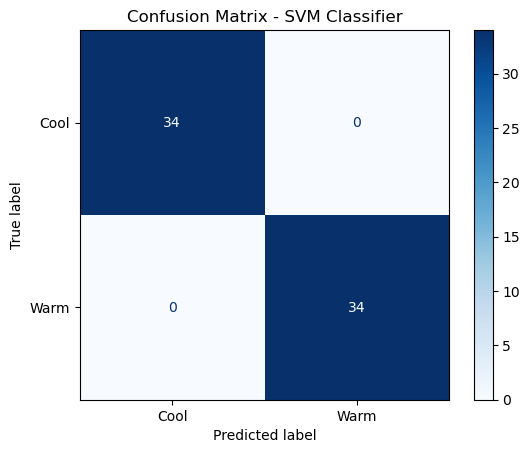

In [81]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cool", "Warm"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SVM Classifier")
plt.show()

## Observations

Observation 1:
The SVM classifier achieved 100% accuracy, correctly classifying all 68 test samples into the Warm and Cool weather categories.

Observation 2:
The precision, recall, and F1-score are all 1.00, indicating perfect classification performance with no false positives or false negatives.

Observation 3:
The confusion matrix shows 34 correctly classified Cool samples and 34 correctly classified Warm samples, with zero misclassifications, demonstrating that the selected weather features effectively distinguish between the two weather classes.

## Conclusion:
In this assignment, a Support Vector Machine (SVM) classifier with an RBF kernel was successfully developed to classify weather conditions into Warm and Cool categories using weather data obtained from the Open-Meteo API. The model achieved 100% accuracy, precision, recall, and F1-score, indicating excellent classification performance on the test dataset. Feature scaling using StandardScaler was an essential preprocessing step because SVM is sensitive to the scale of input features, and scaling ensures that all features contribute equally to the decision boundary. One major advantage of the SVM algorithm is its ability to produce highly accurate classifications, especially for well-separated classes. However, a limitation of SVM is that it can become computationally expensive for large datasets and requires careful selection of kernel and hyperparameters for optimal performance.